###Alumno: Jose Alberto Sabia
###Curso: 2°C
###AÑO:2026
####Materia: Modelizado
####Carrera: Tecnicatura Superior en Ciencia de Datos e IA
####Institución: IFTS 33 - UOCRA
####Profesor: Andres Allievi

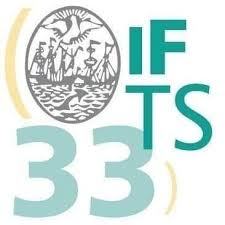

# Desafío Individual: Sistema de Gestión de Obra Inteligente

## Contexto del Problema
Una empresa constructora está desarrollando una torre de gran altura y necesita automatizar dos procesos críticos para garantizar la seguridad y la eficiencia operativa:
* Evaluación de Riesgos en Obra (Lógica Deductiva): Determinar si es seguro continuar con las tareas de altura o excavación basándose en sensores climáticos y estructurales.
* Planificación de Maquinaria Pesada (Satisfacción de Restricciones): Asignar equipos (grúas, excavadoras) a zonas específicas del predio respetando límites de seguridad y espacio físico.

**Misión A:** Diagnóstico de Seguridad con experta

Debes programar un motor de inferencia que reciba datos de sensores y devuelva el nivel de riesgo del sitio. Este sistema actúa como un Cerebro Lógico para evitar accidentes.

Reglas a Implementar:
* **Riesgo Crítico** (Paro de Obra):  Si la velocidad del viento es $> 60\ km/h$ o si se detectan grietas en el suelo de fundación.

---


* **Riesgo Moderado** (Precaución): Si la velocidad del viento está entre $40\ km/h$ y $60\ km/h$ o si hay humedad extrema en zonas de excavación.
* **Bajo Riesgo** (Operación Normal): Si los vientos son $< 40\ km/h$ y no hay alertas estructurales activas.

**Consigna Técnica:** Utiliza el parámetro salience para asegurar que la regla de Riesgo Crítico se evalúe con la máxima prioridad ante cualquier otra condición.El sistema debe imprimir el diagnóstico final y la orden de seguridad correspondiente.

**Misión B:** Ubicación de Equipos con python-constraint

Debes encontrar la distribución óptima de 3 máquinas pesadas en 3 zonas de trabajo distintas. El sistema debe "podar" las opciones que violen las normativas de seguridad.

Restricciones (Reglas de Oro):
* **Grúa Torre:** Solo puede ubicarse en la Zona_Estable (debido a la necesidad de una base de hormigón reforzada).
* **Excavadora:** No puede ingresar a la Zona_Estrecha debido a sus dimensiones.
* **Hormigonera:** No puede estar en la misma zona que la Grúa Torre para evitar congestión de camiones.
* **Exclusividad:** Cada zona solo puede albergar una máquina a la vez para evitar colisiones.Consigna Técnica:Define las variables (Máquinas) y el dominio (Zonas de la obra).

Aplica las funciones de restricción para que el motor de búsqueda encuentre la única configuración válida.

### Mision A

In [ ]:
from experta import *

class EstadoObra(Fact):
    """Datos capturados por sensores en el sitio"""
    pass

class MotorSeguridad(KnowledgeEngine):

    @Rule(AS.f << EstadoObra(viento=P(lambda v: v > 60)) |
          EstadoObra(grietas=True),
          salience=10)
    def riesgo_critico(self):
        print("DIAGNÓSTICO: RIESGO CRÍTICO")
        print("ORDEN: PARO DE OBRA INMEDIATO. Evacuar zonas de altura y excavación.")

    @Rule(AS.f << (EstadoObra(viento=P(lambda v: 40 <= v <= 60)) |
                   EstadoObra(humedad_extrema=True)),
          salience=5)
    def riesgo_moderado(self):
        print("DIAGNÓSTICO: RIESGO MODERADO")
        print("ORDEN: PRECAUCIÓN. Limitar tareas de izaje y monitorear excavaciones.")

    @Rule(EstadoObra(viento=P(lambda v: v < 40),
                     grietas=False,
                     humedad_extrema=False),
          salience=1)
    def bajo_riesgo(self):
        print("DIAGNÓSTICO: BAJO RIESGO")
        print("ORDEN: OPERACIÓN NORMAL. Continuar con el cronograma previsto.")

# --- Prueba del sistema ---
engine = MotorSeguridad()
engine.reset()

# Caso de prueba: Viento de 65 km/h y presencia de grietas
engine.declare(EstadoObra(viento=65, grietas=True, humedad_extrema=False))
engine.run()

### Mision B

In [ ]:
from constraint import *

def resolver_ubicacion():
    problem = Problem()

    # 1. Definir Variables y Dominios
    maquinas = ["Grua_Torre", "Excavadora", "Hormigonera"]
    zonas = ["Zona_Estable", "Zona_Estrecha", "Zona_Abierta"] # Asumimos una tercera zona

    problem.addVariables(maquinas, zonas)

    # 2. Restricción: Exclusividad (Cada zona solo una máquina)
    problem.addConstraint(AllDifferentConstraint())

    # 3. Restricción: Grúa Torre solo en Zona_Estable
    problem.addConstraint(lambda grua: grua == "Zona_Estable", ["Grua_Torre"])

    # 4. Restricción: Excavadora NO en Zona_Estrecha
    problem.addConstraint(lambda exca: exca != "Zona_Estrecha", ["Excavadora"])

    # 5. Restricción: Hormigonera NO con Grúa Torre
    # (Ya está cubierta por AllDifferentConstraint, pero añadimos la lógica de no cercanía si fuera necesaria)
    problem.addConstraint(lambda horm, grua: horm != grua, ["Hormigonera", "Grua_Torre"])

    # 6. Obtener y mostrar solución
    soluciones = problem.getSolutions()

    print(f"Se encontraron {len(soluciones)} configuraciones válidas:")
    for sol in soluciones:
        print(sol)

resolver_ubicacion()

## Parámetros de Entrega y Evaluación
El entregable debe cumplir con lo siguiente:

* **Justificación Funcional:** Debes explicar en celdas de texto por qué el modelo de grafos y árboles es superior a una simple lista de if/else para este problema.
* **Documentación:** El código debe estar respaldado por una explicación de cómo opera el motor de inferencia en cada caso.

*Tener en cuenta que se evalua proceso y no resultado. Acordarse de justificar las elecciones en cada caso.*

¿Por qué es superior un Sistema Experto a una estructura de control tradicional?

Escalabilidad y Mantenibilidad: En un sistema complejo, los if/else anidados se vuelven un "código espagueti" difícil de leer y actualizar. En un motor de inferencia (basado en reglas/grafos), las reglas son independientes. Si mañana la obra agrega una regla sobre "Inundación", solo añades una regla nueva sin modificar toda la estructura lógica existente.

Separación del Conocimiento: Los sistemas expertos separan el conocimiento (las reglas de seguridad) del motor de control (el software que las ejecuta). Esto permite que un experto en seguridad de obra pueda validar las reglas sin necesidad de entender cómo funciona el algoritmo de búsqueda por debajo.

Manejo de Incertidumbre y Prioridades: A diferencia de un if que se ejecuta secuencialmente, el motor de inferencia evalúa el conflicto de reglas. Gracias al parámetro salience, podemos asegurar que la seguridad siempre sea lo primero, sin importar el orden en que los sensores envíen los datos.

Documentación del Proceso (Misión B: Satisfacción de Restricciones)
En lugar de probar todas las combinaciones posibles (fuerza bruta), el motor de python-constraint opera bajo el concepto de Búsqueda con Retroceso (Backtracking) y Poda del Árbol de Búsqueda:

Variables y Dominios: El sistema entiende que tiene 3 objetos (Máquinas) que pueden tomar 3 valores posibles (Zonas).

Poda (Pruning): Tan pronto como el algoritmo intenta asignar la Excavadora a la Zona_Estrecha, el motor detecta la violación de la restricción y descarta esa rama del árbol de decisiones inmediatamente, sin perder tiempo asignando las otras máquinas.

Propagación de Restricciones: Al fijar la Grúa Torre en la Zona_Estable, el sistema automáticamente reduce el dominio de las demás máquinas, asegurando que se llegue a la única solución válida de forma eficiente.